# E-Commerce Customer Behavior: Exploratory Data Analysis

## Project Overview

This project performs Exploratory Data Analysis (EDA) on an e-commerce customer dataset to understand customer purchasing behavior, engagement patterns, spending characteristics, and customer segments.

The analysis focuses on identifying patterns, relationships, correlations, and key factors associated with customer monetary value.

### Objectives

- Understand the structure and characteristics of the dataset
- Perform data quality assessment and statistical analysis
- Analyze customer purchasing and engagement behavior
- Identify relationships between customer attributes
- Examine correlations between behavioral factors and monetary value
- Analyze differences across customer segments
- Identify important patterns and potential outliers
- Derive meaningful and data-driven insights


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Visualization style
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
df = pd.read_csv("../data/raw/ecommerce_user_segmentation.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [5]:
df.head()

,Customer_ID,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Campaign_Response,Wishlist_Adds,Cart_Abandon_Rate,Returns,Segment_Label
0,CUST00001,51,13,1560,113,56,14.77,33,828,1,28,17.63,8,Silver
1,CUST00002,134,5,3,26,7,5.41,2,60,0,4,23.02,9,Iron
2,CUST00003,55,15,235,57,37,5.08,11,710,1,17,28.39,16,Copper
3,CUST00004,46,11,1293,191,48,18.94,20,1223,0,17,15.19,0,Silver
4,CUST00005,21,30,3602,239,90,26.46,37,1892,0,57,11.43,8,Gold


In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 14)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           10000 non-null  object 
 1   Recency               10000 non-null  int64  
 2   Frequency             10000 non-null  int64  
 3   Monetary              10000 non-null  int64  
 4   Avg_Order_Value       10000 non-null  int64  
 5   Session_Count         10000 non-null  int64  
 6   Avg_Session_Duration  10000 non-null  float64
 7   Pages_Viewed          10000 non-null  int64  
 8   Clicks                10000 non-null  int64  
 9   Campaign_Response     10000 non-null  int64  
 10  Wishlist_Adds         10000 non-null  int64  
 11  Cart_Abandon_Rate     10000 non-null  float64
 12  Returns               10000 non-null  int64  
 13  Segment_Label         10000 non-null  object 
dtypes: float64(2), int64(10), object(2)
memory usage: 1.1+ MB


In [8]:
missing_values = df.isnull().sum()

missing_values

Customer_ID             0
Recency                 0
Frequency               0
Monetary                0
Avg_Order_Value         0
Session_Count           0
Avg_Session_Duration    0
Pages_Viewed            0
Clicks                  0
Campaign_Response       0
Wishlist_Adds           0
Cart_Abandon_Rate       0
Returns                 0
Segment_Label           0
dtype: int64

In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

Customer_ID            0.00
Recency                0.00
Frequency              0.00
Monetary               0.00
Avg_Order_Value        0.00
Session_Count          0.00
Avg_Session_Duration   0.00
Pages_Viewed           0.00
Clicks                 0.00
Campaign_Response      0.00
Wishlist_Adds          0.00
Cart_Abandon_Rate      0.00
Returns                0.00
Segment_Label          0.00
dtype: float64

In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [11]:
print("Unique Customer IDs:", df["Customer_ID"].nunique())
print("Unique Segments:", df["Segment_Label"].nunique())

print("\nCustomer Segments:")
print(df["Segment_Label"].value_counts())

Unique Customer IDs: 10000
Unique Segments: 5

Customer Segments:
Segment_Label
Silver      3055
Copper      2444
Gold        2022
Iron        1448
Platinum    1031
Name: count, dtype: int64


In [12]:
df.dtypes

Customer_ID              object
Recency                   int64
Frequency                 int64
Monetary                  int64
Avg_Order_Value           int64
Session_Count             int64
Avg_Session_Duration    float64
Pages_Viewed              int64
Clicks                    int64
Campaign_Response         int64
Wishlist_Adds             int64
Cart_Abandon_Rate       float64
Returns                   int64
Segment_Label            object
dtype: object

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,10000.00,48.67,37.82,1.00,22.00,40.00,63.00,179.00
Frequency,10000.00,28.78,23.13,0.00,10.00,20.00,40.00,99.00
Monetary,10000.00,1938.39,2327.84,0.00,269.00,1022.00,2825.25,9995.00
Avg_Order_Value,10000.00,146.60,87.56,10.00,79.00,135.00,196.00,399.00
Session_Count,10000.00,55.92,43.55,0.00,22.00,44.00,75.00,199.00
Avg_Session_Duration,10000.00,15.44,8.13,1.00,9.52,14.31,19.73,40.00
Pages_Viewed,10000.00,34.00,21.14,1.00,18.00,30.00,46.00,99.00
Clicks,10000.00,1211.47,1058.88,50.00,451.75,871.00,1518.00,4998.00
Campaign_Response,10000.00,0.42,0.49,0.00,0.00,0.00,1.00,1.00
Wishlist_Adds,10000.00,28.62,23.54,0.00,11.00,21.00,41.00,99.00


In [14]:
quality_report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing (%)": (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Values": df.nunique()
})

quality_report

,Data Type,Missing Values,Missing (%),Unique Values
Customer_ID,object,0,0.00,10000
Recency,int64,0,0.00,179
Frequency,int64,0,0.00,100
Monetary,int64,0,0.00,4212
Avg_Order_Value,int64,0,0.00,390
Session_Count,int64,0,0.00,200
Avg_Session_Duration,float64,0,0.00,10000
Pages_Viewed,int64,0,0.00,99
Clicks,int64,0,0.00,3042
Campaign_Response,int64,0,0.00,2


In [15]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate Customer IDs: {df['Customer_ID'].duplicated().sum()}")

Duplicate rows: 0
Duplicate Customer IDs: 0


In [16]:
numerical_columns = df.select_dtypes(include=np.number).columns

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,10000.00,48.67,37.82,1.00,22.00,40.00,63.00,179.00
Frequency,10000.00,28.78,23.13,0.00,10.00,20.00,40.00,99.00
Monetary,10000.00,1938.39,2327.84,0.00,269.00,1022.00,2825.25,9995.00
Avg_Order_Value,10000.00,146.60,87.56,10.00,79.00,135.00,196.00,399.00
Session_Count,10000.00,55.92,43.55,0.00,22.00,44.00,75.00,199.00
Avg_Session_Duration,10000.00,15.44,8.13,1.00,9.52,14.31,19.73,40.00
Pages_Viewed,10000.00,34.00,21.14,1.00,18.00,30.00,46.00,99.00
Clicks,10000.00,1211.47,1058.88,50.00,451.75,871.00,1518.00,4998.00
Campaign_Response,10000.00,0.42,0.49,0.00,0.00,0.00,1.00,1.00
Wishlist_Adds,10000.00,28.62,23.54,0.00,11.00,21.00,41.00,99.00


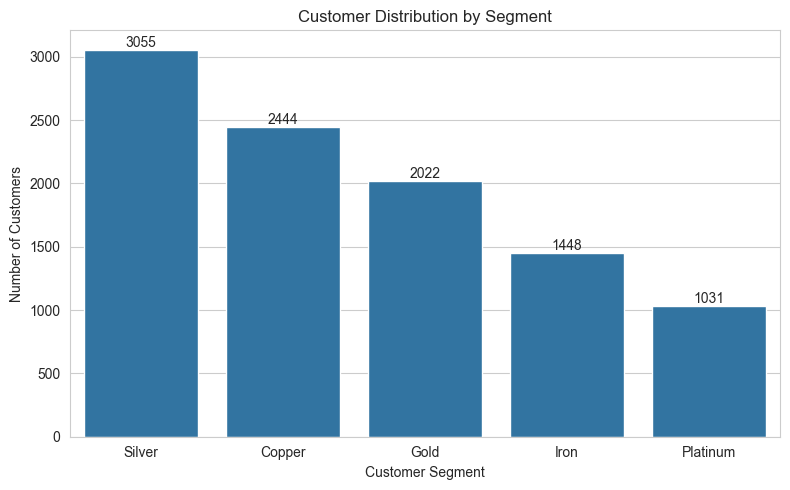

In [17]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Segment_Label",
    order=df["Segment_Label"].value_counts().index
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

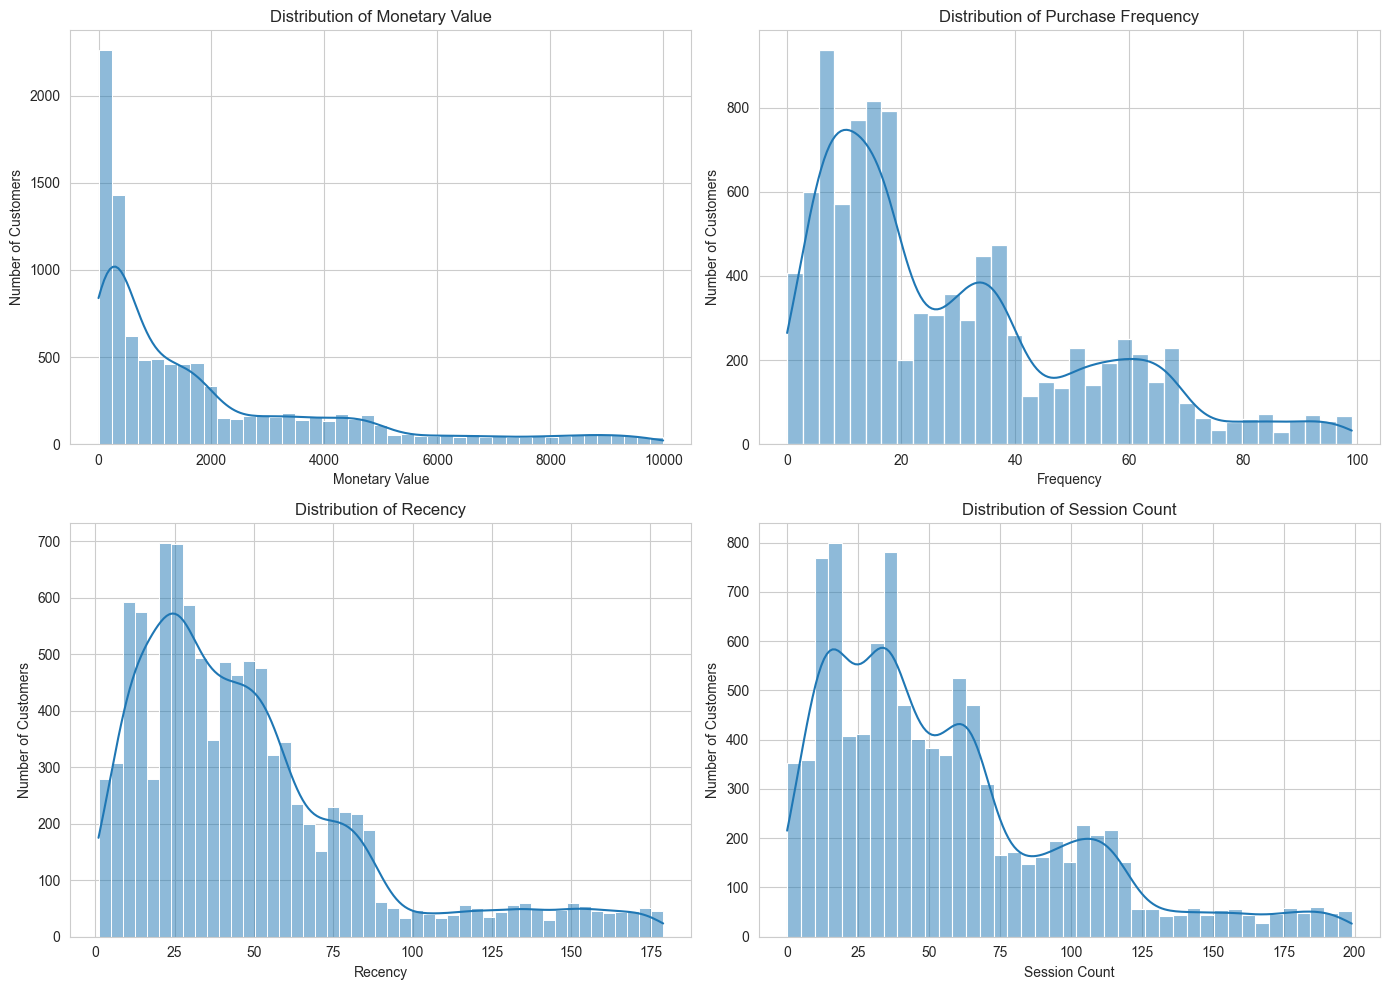

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df["Monetary"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Monetary Value")
axes[0, 0].set_xlabel("Monetary Value")
axes[0, 0].set_ylabel("Number of Customers")

sns.histplot(df["Frequency"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Purchase Frequency")
axes[0, 1].set_xlabel("Frequency")
axes[0, 1].set_ylabel("Number of Customers")

sns.histplot(df["Recency"], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Recency")
axes[1, 0].set_xlabel("Recency")
axes[1, 0].set_ylabel("Number of Customers")

sns.histplot(df["Session_Count"], kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Distribution of Session Count")
axes[1, 1].set_xlabel("Session Count")
axes[1, 1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

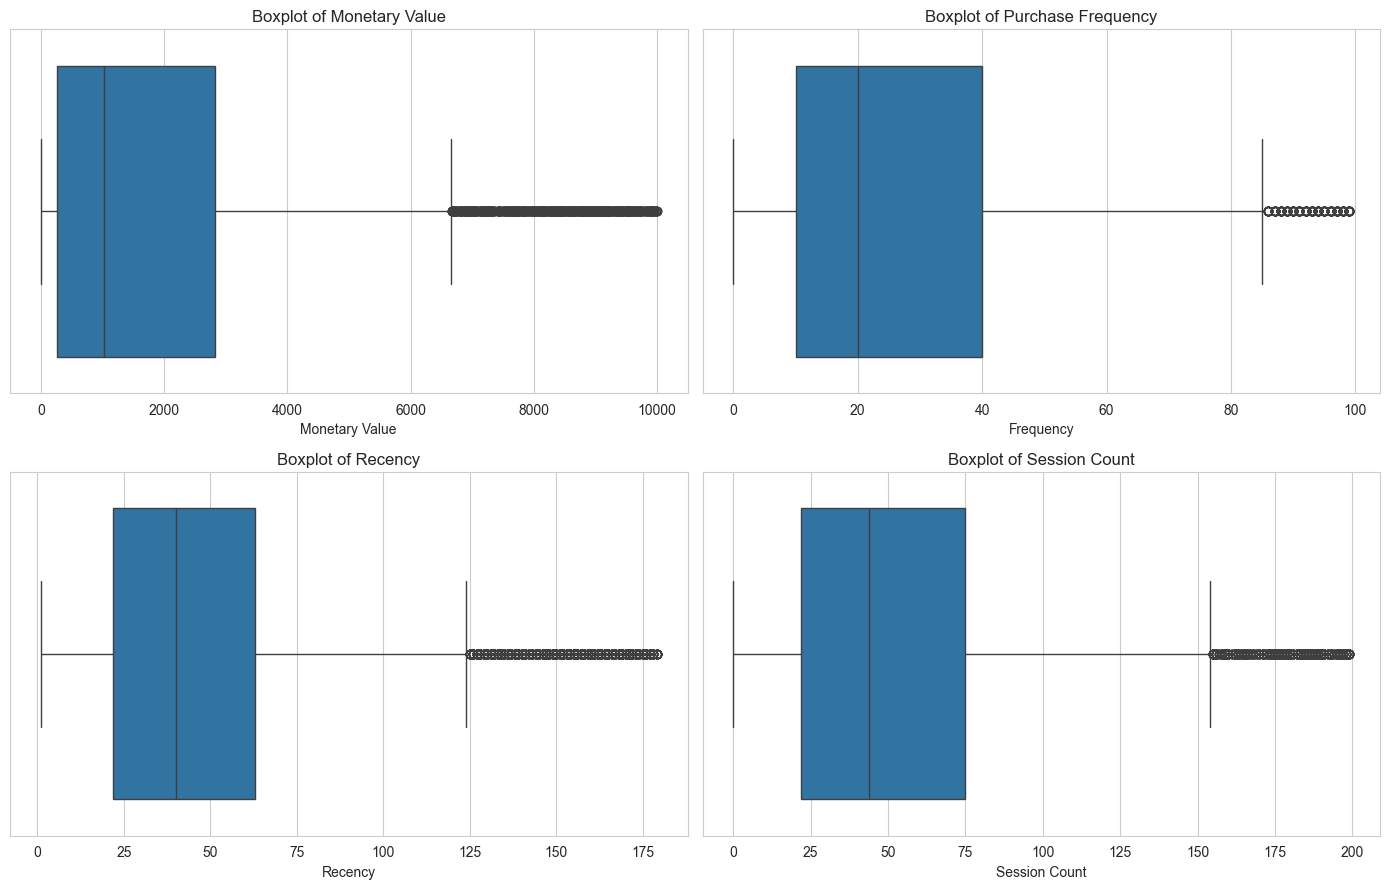

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.boxplot(x=df["Monetary"], ax=axes[0, 0])
axes[0, 0].set_title("Boxplot of Monetary Value")
axes[0, 0].set_xlabel("Monetary Value")

sns.boxplot(x=df["Frequency"], ax=axes[0, 1])
axes[0, 1].set_title("Boxplot of Purchase Frequency")
axes[0, 1].set_xlabel("Frequency")

sns.boxplot(x=df["Recency"], ax=axes[1, 0])
axes[1, 0].set_title("Boxplot of Recency")
axes[1, 0].set_xlabel("Recency")

sns.boxplot(x=df["Session_Count"], ax=axes[1, 1])
axes[1, 1].set_title("Boxplot of Session Count")
axes[1, 1].set_xlabel("Session Count")

plt.tight_layout()
plt.show()

In [20]:
def count_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    return len(outliers), lower_bound, upper_bound


key_columns = [
    "Monetary",
    "Frequency",
    "Recency",
    "Session_Count"
]

outlier_results = []

for column in key_columns:
    count, lower, upper = count_outliers(column)

    outlier_results.append({
        "Variable": column,
        "Outliers": count,
        "Lower Bound": round(lower, 2),
        "Upper Bound": round(upper, 2)
    })

outlier_df = pd.DataFrame(outlier_results)

outlier_df

,Variable,Outliers,Lower Bound,Upper Bound
0,Monetary,674,-3565.38,6659.62
1,Frequency,277,-35.00,85.00
2,Recency,683,-39.50,124.50
3,Session_Count,454,-57.50,154.50


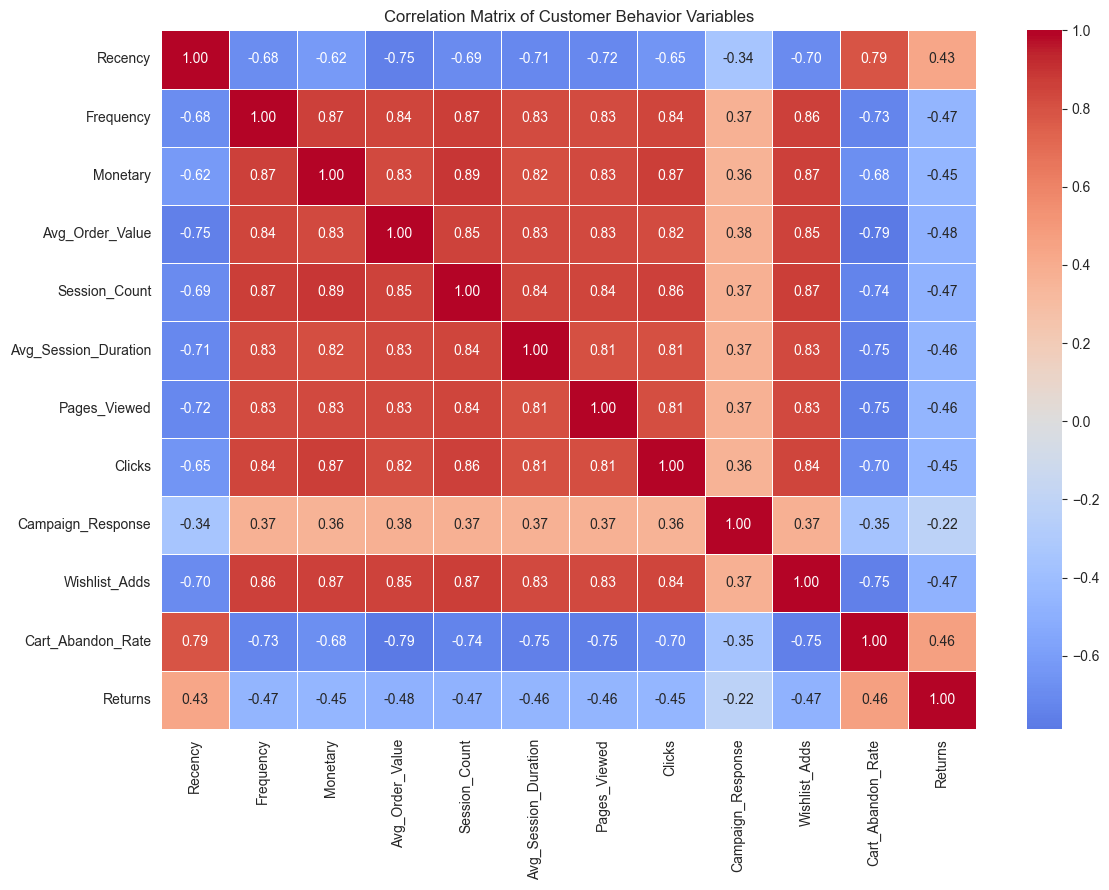

In [21]:
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Customer Behavior Variables")
plt.tight_layout()
plt.show()

In [22]:
monetary_correlation = (
    correlation_matrix["Monetary"]
    .drop("Monetary")
    .sort_values(ascending=False)
)

monetary_correlation

Session_Count           0.89
Clicks                  0.87
Wishlist_Adds           0.87
Frequency               0.87
Pages_Viewed            0.83
Avg_Order_Value         0.83
Avg_Session_Duration    0.82
Campaign_Response       0.36
Returns                -0.45
Recency                -0.62
Cart_Abandon_Rate      -0.68
Name: Monetary, dtype: float64

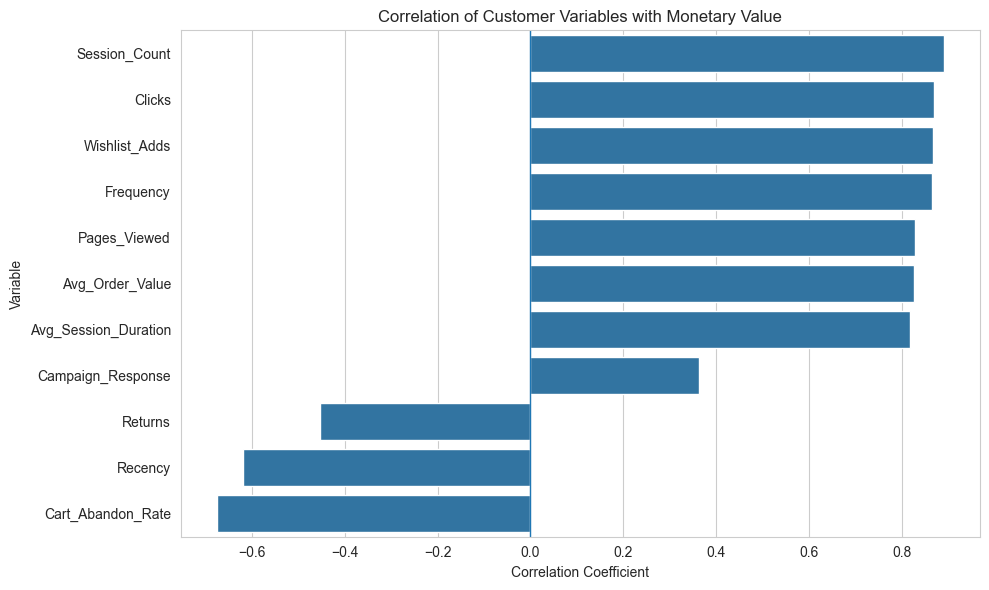

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=monetary_correlation.values,
    y=monetary_correlation.index
)

plt.title("Correlation of Customer Variables with Monetary Value")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Variable")

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

In [24]:
spearman_correlation = (
    df[numerical_columns]
    .corr(method="spearman")["Monetary"]
    .drop("Monetary")
    .sort_values(ascending=False)
)

spearman_correlation

Session_Count           0.92
Avg_Order_Value         0.91
Wishlist_Adds           0.91
Clicks                  0.91
Frequency               0.90
Pages_Viewed            0.89
Avg_Session_Duration    0.88
Campaign_Response       0.39
Returns                -0.47
Recency                -0.88
Cart_Abandon_Rate      -0.89
Name: Monetary, dtype: float64

In [25]:
pearson_monetary = (
    df[numerical_columns]
    .corr(method="pearson")["Monetary"]
    .drop("Monetary")
    .sort_values(ascending=False)
)

pearson_monetary

Session_Count           0.89
Clicks                  0.87
Wishlist_Adds           0.87
Frequency               0.87
Pages_Viewed            0.83
Avg_Order_Value         0.83
Avg_Session_Duration    0.82
Campaign_Response       0.36
Returns                -0.45
Recency                -0.62
Cart_Abandon_Rate      -0.68
Name: Monetary, dtype: float64

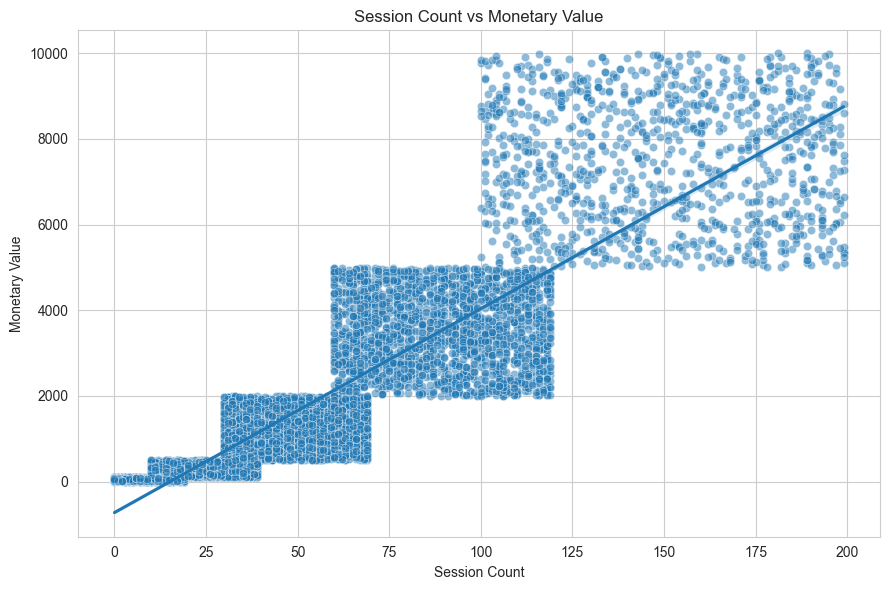

In [26]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Session_Count",
    y="Monetary",
    alpha=0.5
)

sns.regplot(
    data=df,
    x="Session_Count",
    y="Monetary",
    scatter=False
)

plt.title("Session Count vs Monetary Value")
plt.xlabel("Session Count")
plt.ylabel("Monetary Value")

plt.tight_layout()
plt.show()

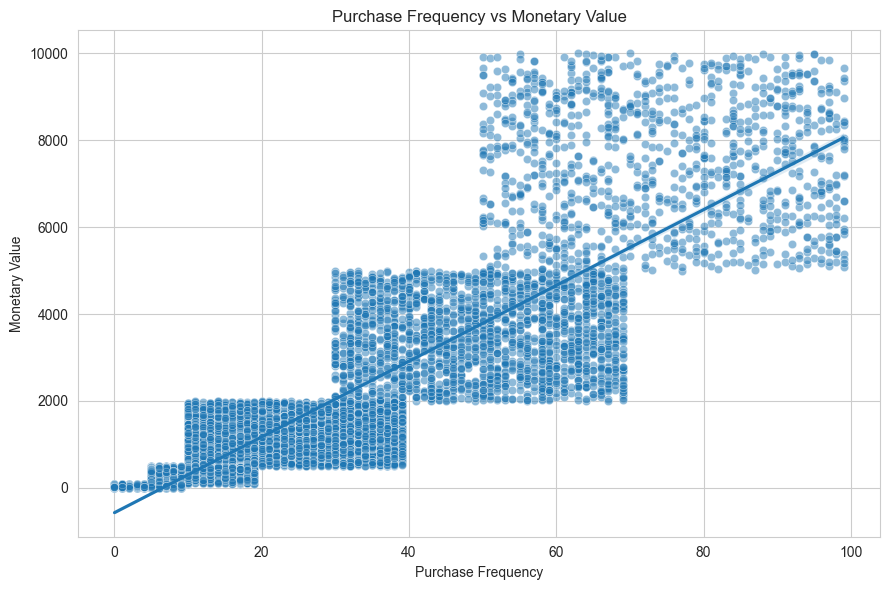

In [27]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Frequency",
    y="Monetary",
    alpha=0.5
)

sns.regplot(
    data=df,
    x="Frequency",
    y="Monetary",
    scatter=False
)

plt.title("Purchase Frequency vs Monetary Value")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")

plt.tight_layout()
plt.show()

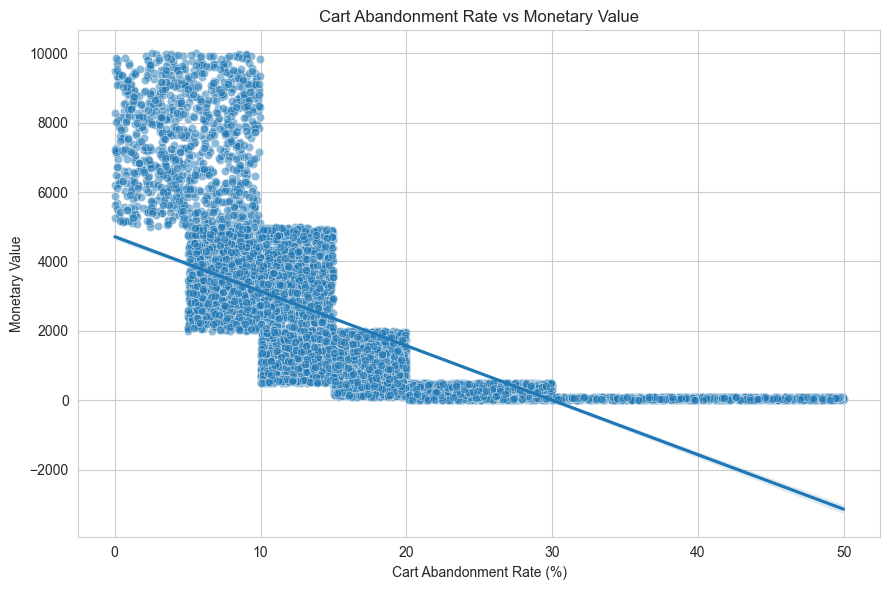

In [28]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Cart_Abandon_Rate",
    y="Monetary",
    alpha=0.5
)

sns.regplot(
    data=df,
    x="Cart_Abandon_Rate",
    y="Monetary",
    scatter=False
)

plt.title("Cart Abandonment Rate vs Monetary Value")
plt.xlabel("Cart Abandonment Rate (%)")
plt.ylabel("Monetary Value")

plt.tight_layout()
plt.show()

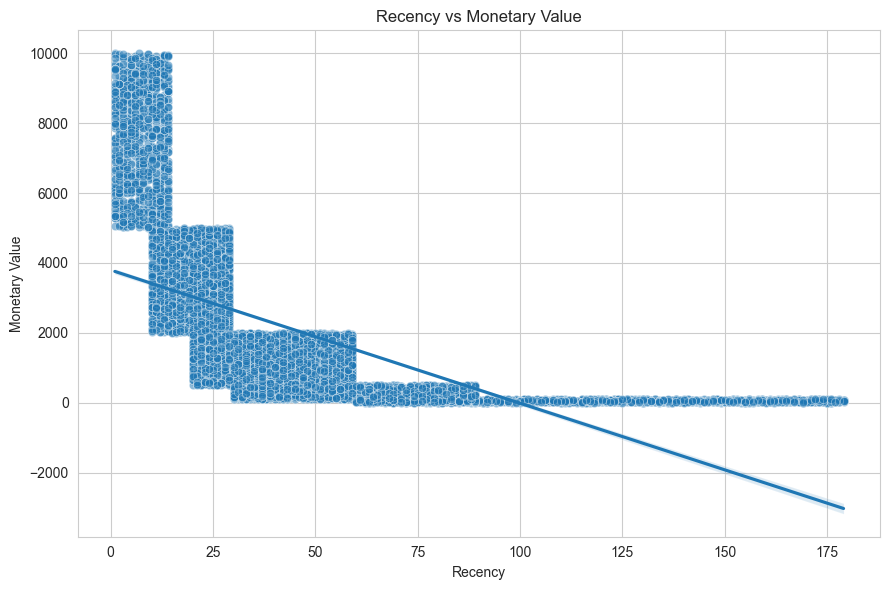

In [29]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Recency",
    y="Monetary",
    alpha=0.5
)

sns.regplot(
    data=df,
    x="Recency",
    y="Monetary",
    scatter=False
)

plt.title("Recency vs Monetary Value")
plt.xlabel("Recency")
plt.ylabel("Monetary Value")

plt.tight_layout()
plt.show()

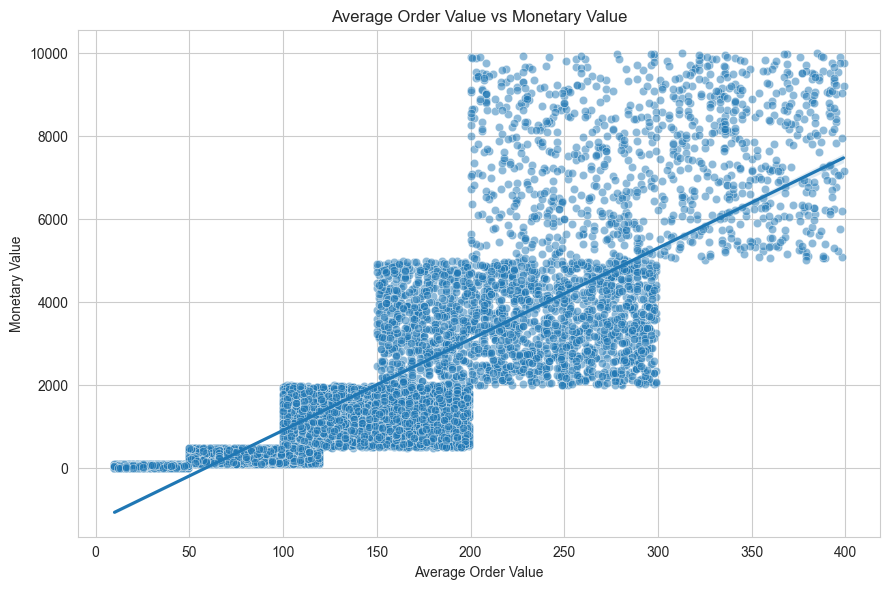

In [30]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Avg_Order_Value",
    y="Monetary",
    alpha=0.5
)

sns.regplot(
    data=df,
    x="Avg_Order_Value",
    y="Monetary",
    scatter=False
)

plt.title("Average Order Value vs Monetary Value")
plt.xlabel("Average Order Value")
plt.ylabel("Monetary Value")

plt.tight_layout()
plt.show()

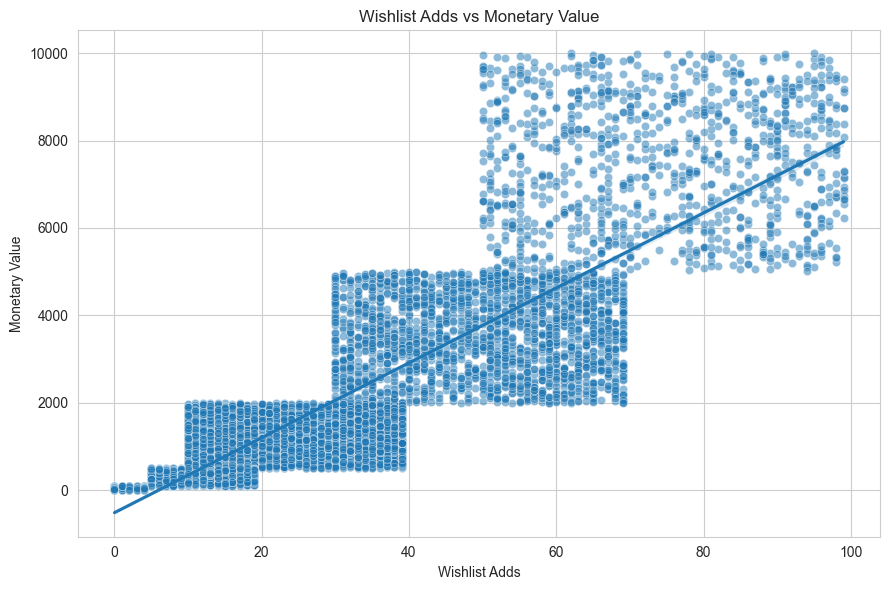

In [31]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Wishlist_Adds",
    y="Monetary",
    alpha=0.5
)

sns.regplot(
    data=df,
    x="Wishlist_Adds",
    y="Monetary",
    scatter=False
)

plt.title("Wishlist Adds vs Monetary Value")
plt.xlabel("Wishlist Adds")
plt.ylabel("Monetary Value")

plt.tight_layout()
plt.show()

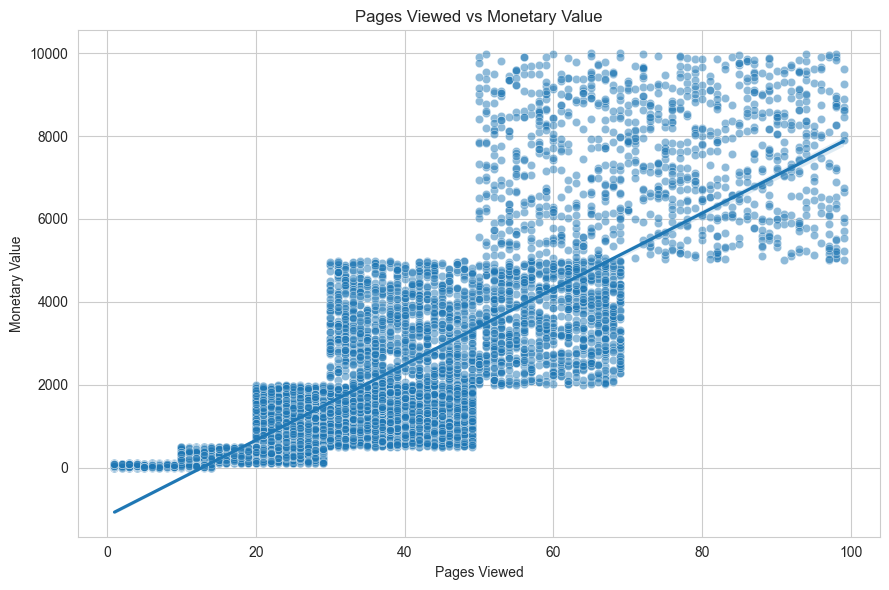

In [32]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Pages_Viewed",
    y="Monetary",
    alpha=0.5
)

sns.regplot(
    data=df,
    x="Pages_Viewed",
    y="Monetary",
    scatter=False
)

plt.title("Pages Viewed vs Monetary Value")
plt.xlabel("Pages Viewed")
plt.ylabel("Monetary Value")

plt.tight_layout()
plt.show()

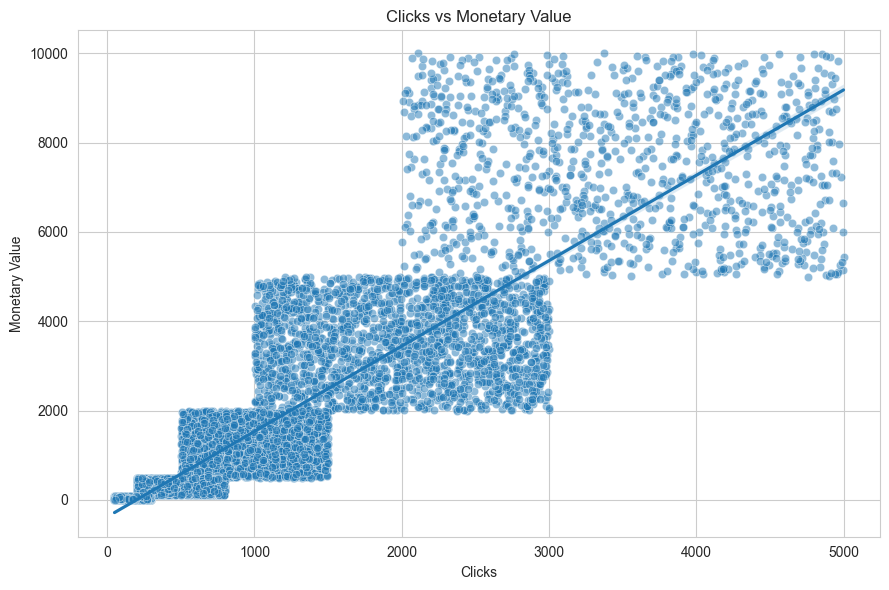

In [33]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Clicks",
    y="Monetary",
    alpha=0.5
)

sns.regplot(
    data=df,
    x="Clicks",
    y="Monetary",
    scatter=False
)

plt.title("Clicks vs Monetary Value")
plt.xlabel("Clicks")
plt.ylabel("Monetary Value")

plt.tight_layout()
plt.show()

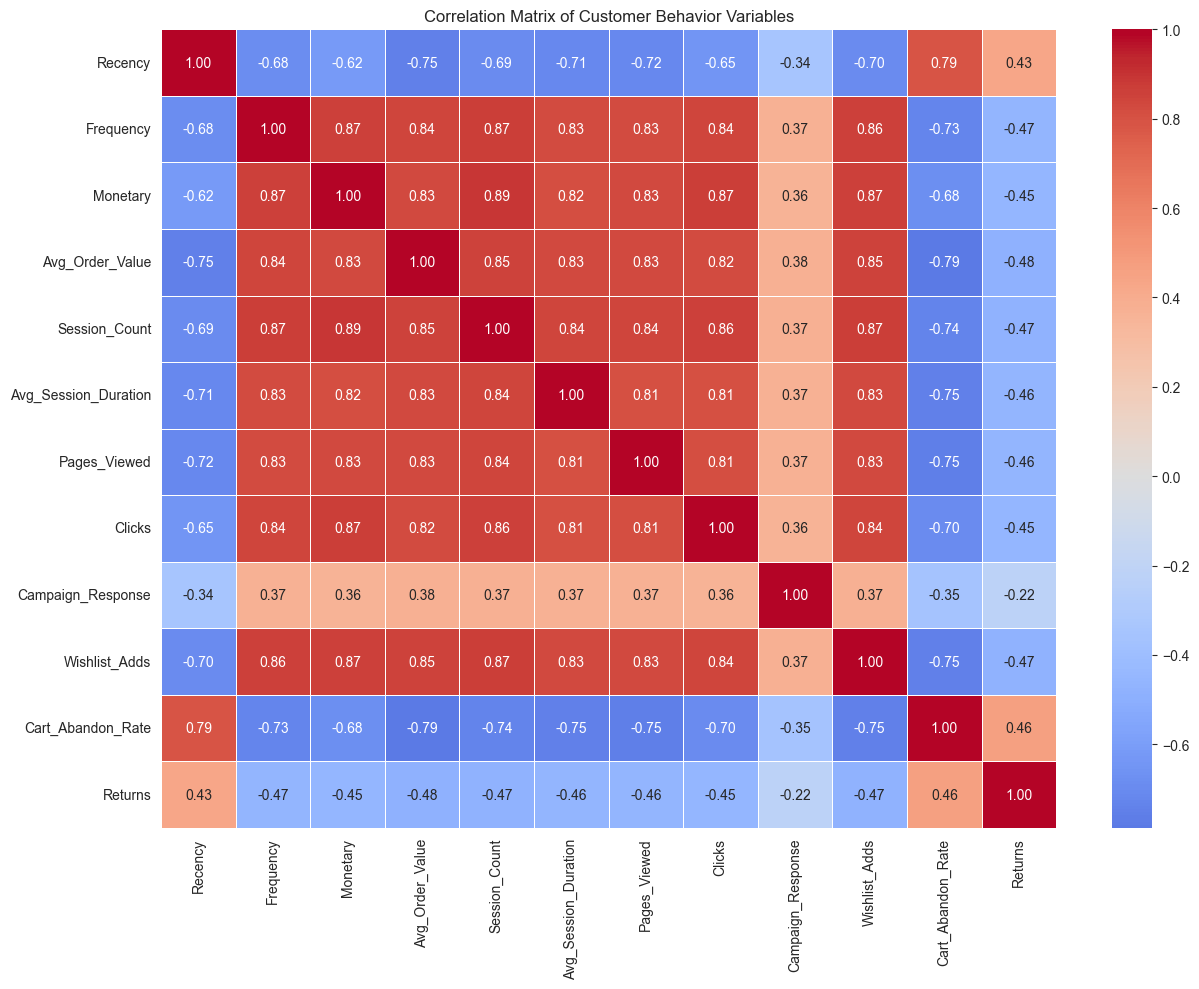

In [34]:
plt.figure(figsize=(13, 10))

correlation_matrix = df[numerical_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Customer Behavior Variables")
plt.tight_layout()
plt.show()

In [35]:
# Display the strongest variable relationships
corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Variable 1", "Variable 2", "Correlation"]

corr_pairs["Absolute Correlation"] = corr_pairs["Correlation"].abs()

corr_pairs.sort_values(
    "Absolute Correlation",
    ascending=False
).head(15)

,Variable 1,Variable 2,Correlation,Absolute Correlation
22,Monetary,Session_Count,0.89,0.89
25,Monetary,Clicks,0.87,0.87
42,Session_Count,Wishlist_Adds,0.87,0.87
13,Frequency,Session_Count,0.87,0.87
27,Monetary,Wishlist_Adds,0.87,0.87
11,Frequency,Monetary,0.87,0.87
40,Session_Count,Clicks,0.86,0.86
18,Frequency,Wishlist_Adds,0.86,0.86
30,Avg_Order_Value,Session_Count,0.85,0.85
35,Avg_Order_Value,Wishlist_Adds,0.85,0.85
